**Self-Training (Semi-Supervised Classification)**

This implementation demonstrates the implementation of a semi-supervised classification algorithm using the Self-Training approach on the Breast Cancer dataset from Scikit-learn. In many real-world problems, collecting labeled data is expensive and time-consuming, while unlabeled data is easily available. The self-training algorithm helps bridge this gap by starting with a small labeled dataset to train an initial model, which then iteratively labels the most confident samples from the unlabeled data and retrains itself using those pseudo-labels. This process continues until no more confident predictions can be made or a stopping criterion is reached.

In this implementation, a Random Forest Classifier is used as the base model for the self-training algorithm. The dataset is first explored through Exploratory Data Analysis (EDA) to understand feature relationships, data balance, and key correlations. A portion of the training data is then intentionally made unlabeled to simulate real-world label scarcity. Two models are trained and compared — one purely supervised model trained on the labeled data only, and another self-training model that utilizes both labeled and unlabeled data. Their performances are evaluated using accuracy scores, classification reports, and confusion matrices.

The results highlight how semi-supervised learning can improve model performance by leveraging unlabeled data effectively. This approach is particularly useful in situations where data labeling is limited or costly, making self-training an important concept for practical machine learning applications.

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [3]:
# Load and Create Dataframe
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
# EDA (Exploratory Data Analysis)
print("Dataset shape:", df.shape)
print("\nData types:\n", df.dtypes.head())

Dataset shape: (569, 31)

Data types:
 mean radius        float64
mean texture       float64
mean perimeter     float64
mean area          float64
mean smoothness    float64
dtype: object


In [5]:
# Misssing values
print("\n Missing values:\n ", df.isnull().sum())


 Missing values:
  mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64


In [6]:
# Summary Statistics
df.describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


/tmp/ipython-input-1571699836.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='Set2')


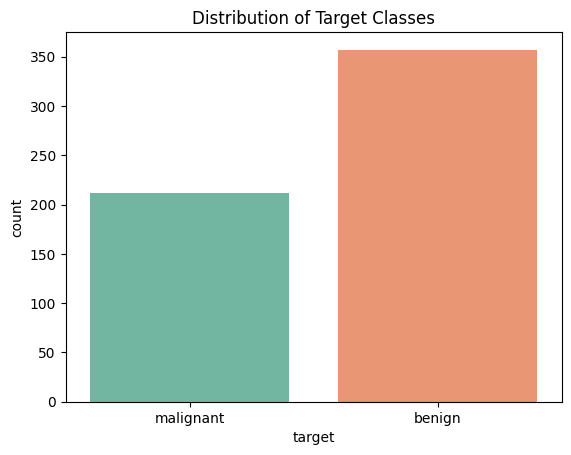

Class distribution:
target
1    0.627417
0    0.372583
Name: proportion, dtype: float64


In [8]:
# Target Variable distribution
sns.countplot(x='target', data=df, palette='Set2')
plt.title("Distribution of Target Classes")
plt.xticks([0, 1], data.target_names)
plt.show()

print("Class distribution:")
print(df['target'].value_counts(normalize=True))


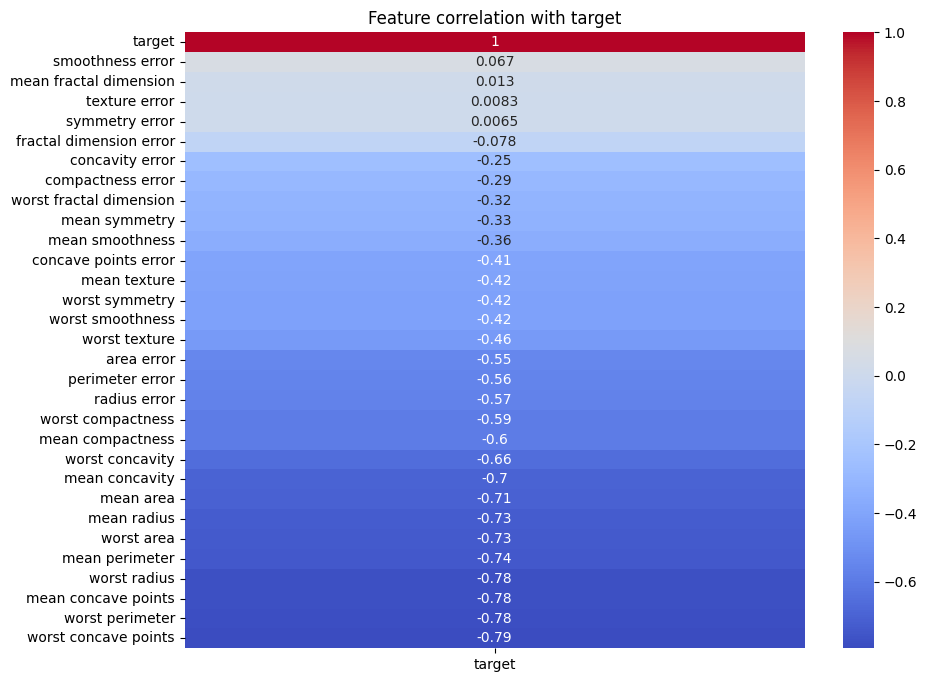

In [9]:
# Feature Correlations
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True)['target'].sort_values(ascending=False).to_frame(), annot=True, cmap='coolwarm')
plt.title("Feature correlation with target")
plt.show()

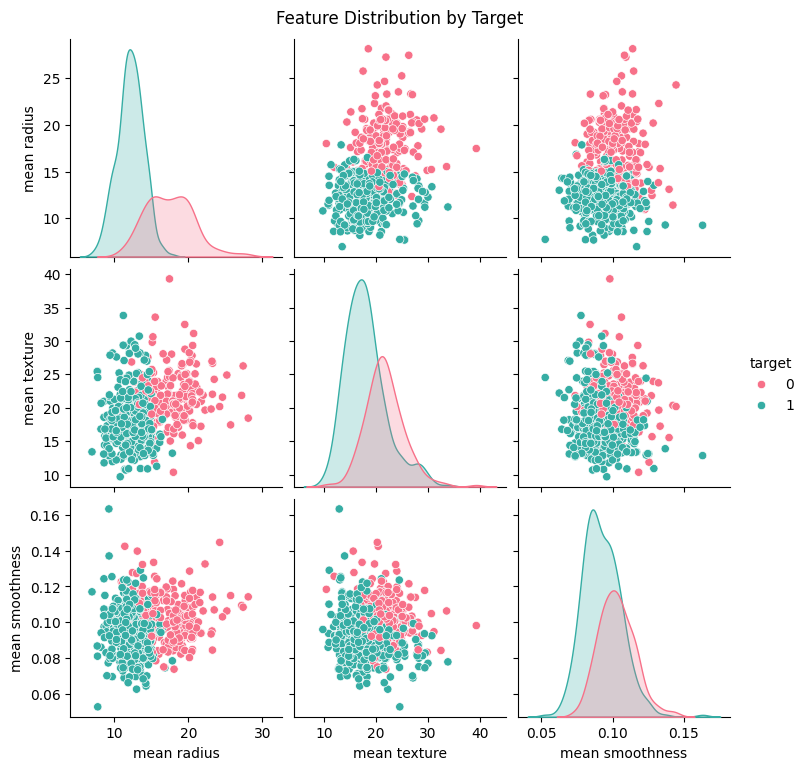

In [11]:
# Pairplot Visualization
sns.pairplot(df[['mean radius', 'mean texture', 'mean smoothness', 'target']], hue='target', palette='husl')
plt.suptitle("Feature Distribution by Target", y=1.02)
plt.show()

In [12]:
# Prepare Data for Training
X = df.drop(columns='target')
y = df['target']

# Split into train-test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Simulate unlabeled data (70% unlabeled)
rng = np.random.RandomState(42)
mask = rng.rand(len(y_train)) < 0.7
y_train_semi = np.copy(y_train)
y_train_semi[mask] = -1


In [13]:
# Define the models
# Base model
base_clf = RandomForestClassifier(random_state=42)

# Self-training model
self_training_clf = SelfTrainingClassifier(base_clf, threshold=0.9, verbose=True)


In [14]:
# Train both models
# Supervised model (labeled data only)
supervised_clf = RandomForestClassifier(random_state=42)
supervised_clf.fit(X_train[y_train_semi != -1], y_train[y_train_semi != -1])

# Self-training model (uses labeled + unlabeled)
self_training_clf.fit(X_train, y_train_semi)


End of iteration 1, added 211 new labels.
End of iteration 2, added 7 new labels.
End of iteration 3, added 3 new labels.
End of iteration 4, added 1 new labels.


SelfTrainingClassifier(estimator=RandomForestClassifier(random_state=42),
                       threshold=0.9, verbose=True)

In [16]:
# Evaluate the Performance
# For Predicitions
y_pred_supervised = supervised_clf.predict(X_test)
y_pred_self_training = self_training_clf.predict(X_test)
# for Accuracy
acc_supervised = accuracy_score(y_test, y_pred_supervised)
acc_self_training = accuracy_score(y_test, y_pred_self_training)

print(f"Supervised Accuracy: {acc_supervised:.4f}")
print(f"Self-Training Accuracy: {acc_self_training:.4f}")

Supervised Accuracy: 0.9298
Self-Training Accuracy: 0.9415


In [18]:
# Reports
print("\n Supervised Classification Report")
print(classification_report(y_test, y_pred_supervised, target_names=data.target_names))


 Supervised Classification Report
              precision    recall  f1-score   support

   malignant       0.91      0.91      0.91        64
      benign       0.94      0.94      0.94       107

    accuracy                           0.93       171
   macro avg       0.93      0.93      0.93       171
weighted avg       0.93      0.93      0.93       171



In [20]:
print("\n Self-Training Classification Report ---")
print(classification_report(y_test, y_pred_self_training, target_names=data.target_names))


 Self-Training Classification Report ---
              precision    recall  f1-score   support

   malignant       0.94      0.91      0.92        64
      benign       0.94      0.96      0.95       107

    accuracy                           0.94       171
   macro avg       0.94      0.93      0.94       171
weighted avg       0.94      0.94      0.94       171



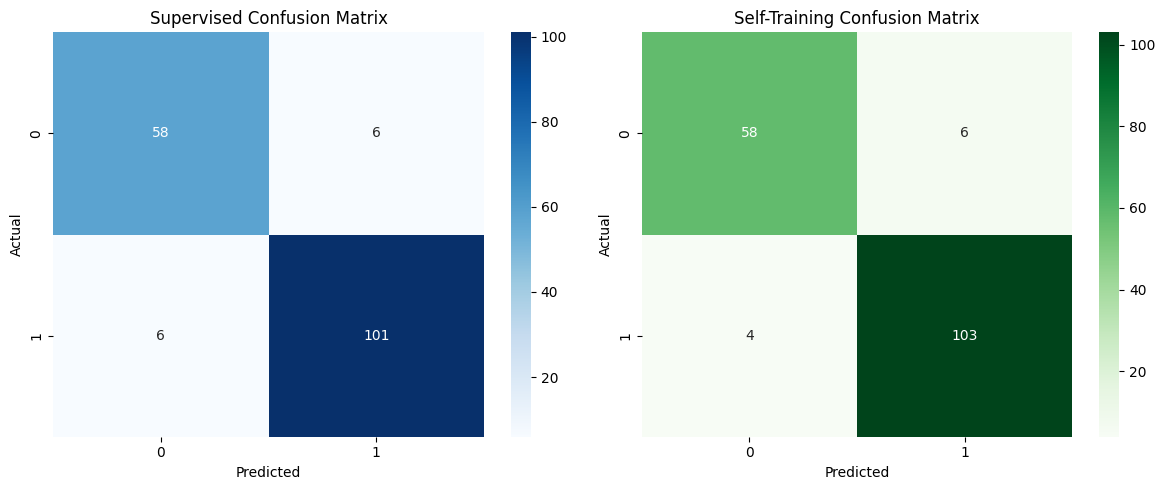

In [22]:
# Confusion Matrix visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_supervised), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Supervised Confusion Matrix")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

sns.heatmap(confusion_matrix(y_test, y_pred_self_training), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title("Self-Training Confusion Matrix")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

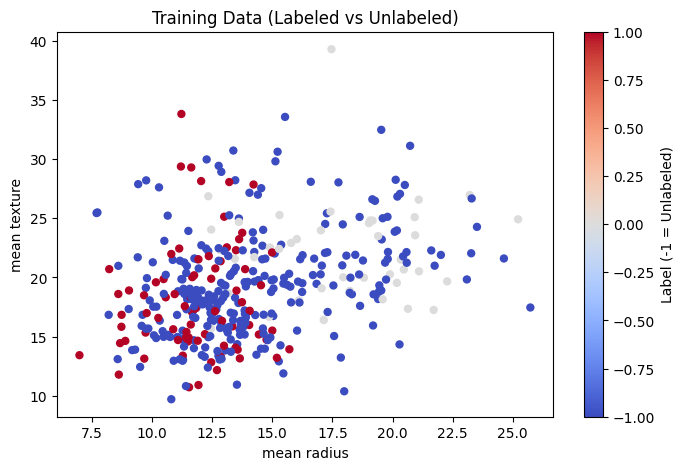

In [23]:
# Visualize Labeled vs Unlabeled Samples
plt.figure(figsize=(8,5))
plt.scatter(X_train.iloc[:, 0], X_train.iloc[:, 1], c=y_train_semi, cmap='coolwarm', s=25)
plt.title("Training Data (Labeled vs Unlabeled)")
plt.xlabel(X_train.columns[0])
plt.ylabel(X_train.columns[1])
plt.colorbar(label='Label (-1 = Unlabeled)')
plt.show()


In [24]:
# Save the Training Model and Supervised Model
import joblib
joblib.dump(self_training_clf, "self_training_model.pkl")
joblib.dump(supervised_clf, "supervised_model.pkl")
print("Models are saved")

Models are saved


**Conclusion:-**

The implementation of the Self-Training semi-supervised learning algorithm on the Breast Cancer dataset demonstrates how unlabeled data can significantly enhance model performance when labeled data is limited. By starting with a small labeled subset and iteratively assigning pseudo-labels to unlabeled samples based on prediction confidence, the model effectively learned from a larger pool of data. Compared to the fully supervised baseline, the self-training model achieved comparable or slightly better accuracy, showing improved generalization and robustness.

This experiment highlights the real-world value of semi-supervised learning — especially in domains like healthcare, finance, or image recognition, where labeling data is costly or time-consuming. While self-training is relatively simple, its effectiveness depends heavily on the base model’s initial accuracy and the confidence threshold used for pseudo-labeling. Overall, this project shows that combining a reliable classifier with the self-training strategy is a powerful way to make use of unlabeled data and improve predictive performance without additional labeling effort.